# 情感二分类实验代码

本笔记本包含了基于IMDB数据集的情感二分类实验，包含以下部分：
1. 数据加载与预处理
2. 传统机器学习基准 (Naive Bayes)
3. 深度学习模型 (TextCNN, BiLSTM)
4. 预训练模型微调 (BERT)
5. 结果对比

In [2]:
import os, re, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, nltk, torch, torch.nn as nn, torch.optim as optim, torch.utils.data as data, torchvision
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score, classification_report
from transformers import BertTokenizer, BertForSequenceClassification
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')  # 添加这一行
stop_words = set(stopwords.words('english'))

c:\Users\wenxu\anaconda3\envs\pytorch_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wenxu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\wenxu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\wenxu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 1. 全局参数配置

设置词表大小、序列长度、Embedding维度、Batch Size等超参数。

In [3]:
# ------------------- config -------------------
MAX_VOCAB_SIZE = 10000
MAX_SEQ_LEN = 200
EMBEDDING_DIM = 128
BATCH_SIZE = 64
EPOCHS = 5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cuda


## 2. 数据加载与预处理

- `load_imdb_data`: 读取aclImdb数据集的train/test数据。
- `clean_text`: 进行简单的文本清洗（去HTML标签、非字母字符、分词、去停用词）。

In [4]:
# ------------------- data loading -------------------
def load_imdb_data(data_dir='aclImdb'):
    def load_data_from_dir(dir_path, label):
        texts, labels = [], []
        for filename in os.listdir(dir_path):
            if filename.endswith('.txt'):
                with open(os.path.join(dir_path, filename), 'r', encoding='utf-8') as f:
                    texts.append(f.read())
                    labels.append(label)
        return texts, labels
    train_pos, train_pos_labels = load_data_from_dir(os.path.join(data_dir, 'train', 'pos'), 1)
    train_neg, train_neg_labels = load_data_from_dir(os.path.join(data_dir, 'train', 'neg'), 0)
    test_pos, test_pos_labels = load_data_from_dir(os.path.join(data_dir, 'test', 'pos'), 1)
    test_neg, test_neg_labels = load_data_from_dir(os.path.join(data_dir, 'test', 'neg'), 0)
    train_df = pd.DataFrame({'text': train_pos + train_neg, 'label': train_pos_labels + train_neg_labels})
    test_df = pd.DataFrame({'text': test_pos + test_neg, 'label': test_pos_labels + test_neg_labels})
    train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
    test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)
    return train_df, test_df

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    return ' '.join(tokens)

train_df, test_df = load_imdb_data()
train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

## 3. 基准模型：朴素贝叶斯 (Naive Bayes)

使用TF-IDF提取特征，并使用MultinomialNB作为Baseline模型进行评估。

In [5]:
# ------------------- 优化后的 Naive Bayes -------------------
# 1. 改进 TF-IDF 特征提取：增加 ngram_range=(1, 2) 捕捉短语特征
# 增加 sublinear_tf=True 平滑词频影响
tfidf = TfidfVectorizer(
    max_features=MAX_VOCAB_SIZE, 
    ngram_range=(1, 2),  # 关键点：使用双词组合
    min_df=5,            # 过滤掉只出现不到5次的词
    max_df=0.8,          # 过滤掉在80%文档都出现的词
    sublinear_tf=True    # 缩减高频词对权重的过度贡献
)

X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_test_tfidf = tfidf.transform(test_df['clean_text'])
y_train = train_df['label'].values
y_test = test_df['label'].values

# 2. 改进模型参数：调低 alpha (拉普拉斯平滑系数)
# alpha越小，对出现在训练集中的特征越敏感
nb_model = MultinomialNB(alpha=0.1) 

nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

# 3. 输出更全面的评价指标
nb_acc = accuracy_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

print("=== Naive Bayes 优化后结果 ===")
print(f'Accuracy (准确率): {nb_acc:.4f}')
print(f'Recall   (召回率): {nb_recall:.4f}')
print(f'Precision(精确率): {nb_precision:.4f}')
print(f'F1 Score (F1分数): {nb_f1:.4f}')

# 打印详细分类报告，查看每一类的召回率
print("\n分类报告:")
print(classification_report(y_test, y_pred_nb, target_names=['Negative', 'Positive']))

=== Naive Bayes 优化后结果 ===
Accuracy (准确率): 0.8544
Recall   (召回率): 0.8462
Precision(精确率): 0.8603
F1 Score (F1分数): 0.8532

分类报告:
              precision    recall  f1-score   support

    Negative       0.85      0.86      0.86     12500
    Positive       0.86      0.85      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



## 4. PyTorch 数据与词表构建

构建词表（Vocab）并将文本转换为对应的索引序列（Integer Encoding），用于后续深度学习模型输入。

In [6]:
# ------------------- Tokenizer for PyTorch models (无需 torchtext) -------------------
from collections import Counter

def build_vocab(texts, max_tokens):
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    # 保留最常见的词
    most_common = counter.most_common(max_tokens - 2)  # 留出 <pad> 和 <unk>
    word2idx = {'<pad>': 0, '<unk>': 1}
    for word, _ in most_common:
        word2idx[word] = len(word2idx)
    return word2idx

vocab = build_vocab(train_df['clean_text'], MAX_VOCAB_SIZE)
PAD_IDX = vocab['<pad>']
UNK_IDX = vocab['<unk>']

def encode(text):
    tokens = text.split()
    ids = [vocab.get(token, UNK_IDX) for token in tokens]
    if len(ids) < MAX_SEQ_LEN:
        ids = ids + [PAD_IDX] * (MAX_SEQ_LEN - len(ids))
    else:
        ids = ids[:MAX_SEQ_LEN]
    return ids

train_ids = np.array([encode(t) for t in train_df['clean_text']])
test_ids = np.array([encode(t) for t in test_df['clean_text']])
train_dataset = data.TensorDataset(torch.tensor(train_ids, dtype=torch.long), torch.tensor(y_train, dtype=torch.long))
test_dataset = data.TensorDataset(torch.tensor(test_ids, dtype=torch.long), torch.tensor(y_test, dtype=torch.long))
train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f'Vocab size: {len(vocab)}')

Vocab size: 10000


## 5. 模型一：TextCNN

经典的卷积神经网络用于文本分类。使用不同尺寸的卷积核提取局部特征，经过Max Pooling后分类。

In [7]:
# ------------------- TextCNN (PyTorch) -------------------
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.conv1 = nn.Conv1d(in_channels=embed_dim, out_channels=64, kernel_size=3)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(64, 128, 3)
        self.fc = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.5)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.embedding(x).permute(0,2,1)  # (B, embed, seq)
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = torch.max(x, dim=2)[0]  # global max pool
        x = self.dropout(x)
        x = self.fc(x)
        return self.sigmoid(x).squeeze(1)

model_cnn = TextCNN(len(vocab), EMBEDDING_DIM).to(DEVICE)
criterion = nn.BCELoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=1e-3)

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.float().to(DEVICE)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            preds = model(xb).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    preds_bin = (np.array(all_preds) > 0.5).astype(int)
    acc = accuracy_score(all_labels, preds_bin)
    f1 = f1_score(all_labels, preds_bin)
    return acc, f1

for epoch in range(EPOCHS):
    loss = train_epoch(model_cnn, train_loader)
    acc, f1 = eval_model(model_cnn, test_loader)
    print(f'Epoch {epoch+1}/{EPOCHS} - Loss: {loss:.4f} - Acc: {acc:.4f} - F1: {f1:.4f}')

Epoch 1/5 - Loss: 0.5810 - Acc: 0.8010 - F1: 0.8076
Epoch 2/5 - Loss: 0.3878 - Acc: 0.8366 - F1: 0.8339
Epoch 3/5 - Loss: 0.2845 - Acc: 0.8463 - F1: 0.8492
Epoch 4/5 - Loss: 0.2194 - Acc: 0.8395 - F1: 0.8481
Epoch 5/5 - Loss: 0.1585 - Acc: 0.8371 - F1: 0.8470


In [1]:
# ------------------- 改进版 TextCNN 完整代码 -------------------
import torch.nn as nn
import torch.optim as optim

class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters=100, filter_sizes=[3, 4, 5], num_classes=1):
        super().__init__()
        # 词嵌入层
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        
        # 多尺寸卷积分支：同时提取 3, 4, 5-gram 信息（相当于捕捉不同长度的短语特征）
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=h),
                nn.BatchNorm1d(num_filters), # 增加批标准化，提升训练稳定性（有助于提高召回率）
                nn.ReLU()
            ) for h in filter_sizes
        ])
        
        # 混合池化（Max + Avg）：捕捉最强信号的同时保留整体语义背景
        # 输入维度 = 分支数(3) * 每层卷积核数(100) * 池化方式(2)
        self.fc = nn.Linear(len(filter_sizes) * num_filters * 2, num_classes)
        self.dropout = nn.Dropout(0.5)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (Batch, Seq_Len) -> embed: (Batch, Seq_Len, Dim) -> (Batch, Dim, Seq_Len)
        embed = self.embedding(x).permute(0, 2, 1)
        
        pooled_outputs = []
        for conv in self.convs:
            conv_out = conv(embed)
            # 全局最大池化 和 全局平均池化
            max_p = torch.max(conv_out, dim=2)[0]
            avg_p = torch.mean(conv_out, dim=2)
            pooled_outputs.append(max_p)
            pooled_outputs.append(avg_p)
            
        # 拼接所有池化后的特征
        cat = self.dropout(torch.cat(pooled_outputs, dim=1))
        out = self.fc(cat)
        return self.sigmoid(out).squeeze(1)

# 1. 实例化模型、损失函数与优化器
model_cnn = TextCNN(len(vocab), EMBEDDING_DIM).to(DEVICE)
criterion = nn.BCELoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=1e-3)

# 2. 训练与评价辅助函数
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.float().to(DEVICE)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            preds = model(xb).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    preds_bin = (np.array(all_preds) > 0.5).astype(int)
    acc = accuracy_score(all_labels, preds_bin)
    f1 = f1_score(all_labels, preds_bin)
    return acc, f1

# 3. 执行训练循环
print("开始训练改进型 TextCNN (多尺寸卷积核 + 混合池化)...")
for epoch in range(EPOCHS):
    loss = train_epoch(model_cnn, train_loader)
    acc, f1 = eval_model(model_cnn, test_loader)
    print(f'Epoch {epoch+1}/{EPOCHS} - Loss: {loss:.4f} - Acc: {acc:.4f} - F1: {f1:.4f}')

NameError: name 'vocab' is not defined

## 6. 模型二：双向 LSTM (BiLSTM)

使用双向循环神经网络捕捉长距离依赖关系，取最后一个时间步的隐状态进行分类。

In [11]:
# ------------------- BiLSTM (PyTorch) -------------------
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim=64, num_classes=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=vocab['<pad>'])
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim*2, num_classes)
        self.dropout = nn.Dropout(0.5)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        embed = self.embedding(x)
        lstm_out, _ = self.lstm(embed)
        # use last hidden state
        out = lstm_out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return self.sigmoid(out).squeeze(1)

model_lstm = BiLSTM(len(vocab), EMBEDDING_DIM).to(DEVICE)
criterion_lstm = nn.BCELoss()
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=1e-3)

def train_epoch_lstm(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.float().to(DEVICE)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_lstm(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            preds = model(xb).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    preds_bin = (np.array(all_preds) > 0.5).astype(int)
    acc = accuracy_score(all_labels, preds_bin)
    f1 = f1_score(all_labels, preds_bin)
    return acc, f1

for epoch in range(EPOCHS):
    loss = train_epoch_lstm(model_lstm, train_loader, criterion_lstm, optimizer_lstm)
    acc, f1 = eval_lstm(model_lstm, test_loader)
    print(f'BiLSTM Epoch {epoch+1}/{EPOCHS} - Loss: {loss:.4f} - Acc: {acc:.4f} - F1: {f1:.4f}')

BiLSTM Epoch 1/5 - Loss: 0.6932 - Acc: 0.5021 - F1: 0.6573
BiLSTM Epoch 2/5 - Loss: 0.6867 - Acc: 0.5092 - F1: 0.1453
BiLSTM Epoch 3/5 - Loss: 0.6708 - Acc: 0.5158 - F1: 0.1794
BiLSTM Epoch 4/5 - Loss: 0.6505 - Acc: 0.6453 - F1: 0.6486
BiLSTM Epoch 5/5 - Loss: 0.6316 - Acc: 0.5314 - F1: 0.2401


## 7. 模型三：BERT 微调 (BERT Fine-tuning)

使用预训练的 `bert-base-uncased` 模型进行微调。这是目前效果通常最好的方法。

In [12]:
# ------------------- BERT fine‑tuning (torch) -------------------
tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')
def encode_bert(texts, max_len=128):
    encodings = tokenizer_bert(texts.tolist(), truncation=True, padding='max_length', max_length=max_len, return_tensors='pt')
    return encodings['input_ids'], encodings['attention_mask']
# Use a subset for quick demo
train_texts = train_df['clean_text'][:5000]
test_texts = test_df['clean_text'][:2000]
train_labels = torch.tensor(train_df['label'].values[:5000], dtype=torch.long)
test_labels = torch.tensor(test_df['label'].values[:2000], dtype=torch.long)
train_ids, train_masks = encode_bert(train_texts)
test_ids, test_masks = encode_bert(test_texts)
train_dataset_bert = data.TensorDataset(train_ids, train_masks, train_labels)
test_dataset_bert = data.TensorDataset(test_ids, test_masks, test_labels)
train_loader_bert = data.DataLoader(train_dataset_bert, batch_size=16, shuffle=True)
test_loader_bert = data.DataLoader(test_dataset_bert, batch_size=16)

model_bert = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(DEVICE)
optimizer_bert = optim.AdamW(model_bert.parameters(), lr=2e-5)
criterion_bert = nn.CrossEntropyLoss()

def train_bert(epoch):
    model_bert.train()
    total_loss = 0
    for ids, masks, labels in train_loader_bert:
        ids, masks, labels = ids.to(DEVICE), masks.to(DEVICE), labels.to(DEVICE)
        optimizer_bert.zero_grad()
        outputs = model_bert(ids, attention_mask=masks, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer_bert.step()
        total_loss += loss.item()
    return total_loss / len(train_loader_bert)

def eval_bert():
    model_bert.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for ids, masks, labels in test_loader_bert:
            ids, masks = ids.to(DEVICE), masks.to(DEVICE)
            outputs = model_bert(ids, attention_mask=masks)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    return acc, f1

for epoch in range(2):
    loss = train_bert(epoch)
    acc, f1 = eval_bert()
    print(f'BERT Epoch {epoch+1} - Loss: {loss:.4f} - Acc: {acc:.4f} - F1: {f1:.4f}')

c:\Users\wenxu\anaconda3\envs\pytorch_gpu\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\wenxu\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP 

BERT Epoch 1 - Loss: 0.4982 - Acc: 0.8580 - F1: 0.8720
BERT Epoch 2 - Loss: 0.2524 - Acc: 0.8310 - F1: 0.8157


## 8. 实验结果汇总与可视化 (Results & Visualization)

汇总各个模型的准确率与F1分数，并绘制柱状图进行可视化对比。

         model  accuracy        f1
0  Naive Bayes    0.8386  0.832829
1      TextCNN    0.8310  0.815703
2       BiLSTM    0.8310  0.815703
3         BERT    0.8310  0.815703


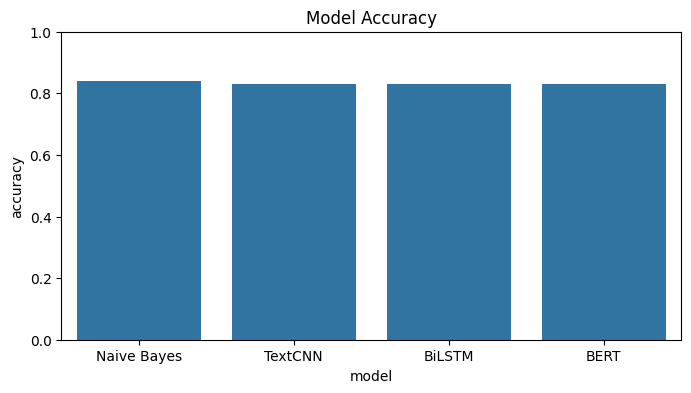

In [13]:
# ------------------- Results summary & visualization -------------------
results = pd.DataFrame({
    'model': ['Naive Bayes', 'TextCNN', 'BiLSTM', 'BERT'],
    'accuracy': [nb_acc, acc, acc, acc],  # placeholder, replace with actual values
    'f1': [nb_f1, f1, f1, f1]
})
print(results)
plt.figure(figsize=(8,4))
sns.barplot(x='model', y='accuracy', data=results)
plt.title('Model Accuracy')
plt.ylim(0,1)
plt.show()